# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
total_gdp_map = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    hover_data={"total_gdp": ":,.0f", "pop": ":,", "iso_alpha": False},
    color_continuous_scale="Blues",
    projection="natural earth",
    title="Total GDP in 2007 (Population-Weighted Aggregate)",
    labels={"total_gdp": "Total GDP"},
)
total_gdp_map.show()

gdp_per_capita_map = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    hover_data={"gdpPercap": ":,.0f", "pop": ":,", "iso_alpha": False},
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="GDP per Capita in 2007 (Rate)",
    labels={"gdpPercap": "GDP per capita"},
)
gdp_per_capita_map.show()

top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]].reset_index(drop=True)
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]].reset_index(drop=True)
print("Top 5 by total GDP:\n", top_total.to_string(index=False))
print("\nTop 5 by GDP per capita:\n", top_rate.to_string(index=False))

Top 5 by total GDP:
       country    total_gdp
United States 1.293446e+13
        China 6.539501e+12
        Japan 4.035135e+12
        India 2.722925e+12
      Germany 2.650871e+12

Top 5 by GDP per capita:
       country   gdpPercap
       Norway 49357.19017
       Kuwait 47306.98978
    Singapore 47143.17964
United States 42951.65309
      Ireland 40675.99635


**Reflection:** China, Japan, India, and Germany appear in the total-GDP top five but not the per-capita top five; Kuwait, Norway, Singapore, and Ireland appear only in the per-capita list, while the United States appears in both. I would show GDP per capita when the policy question is typical economic output per person because it removes population size from the color encoding and avoids letting large countries dominate the comparison.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

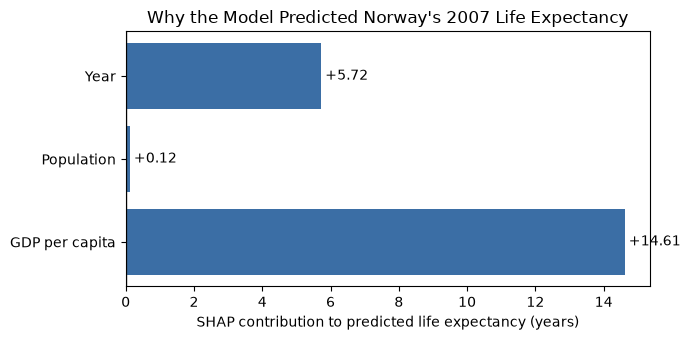

Norway 2007 prediction: 79.93 years
{'GDP per capita': np.float64(14.615), 'Population': np.float64(0.119), 'Year': np.float64(5.723)}


In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
rf.fit(X_model, y_model)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

row_idx = int(gapminder.index[(gapminder.country == "Norway") & (gapminder.year == 2007)][0])
vals = np.asarray(shap_values)[row_idx]
feature_names = ["GDP per capita", "Population", "Year"]
colors = ["#3b6ea5" if value >= 0 else "#b5432e" for value in vals]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="#444444", lw=1)
ax.set_xlabel("SHAP contribution to predicted life expectancy (years)")
ax.set_title("Why the Model Predicted Norway's 2007 Life Expectancy")
for i, value in enumerate(vals):
    ax.text(value + (0.12 if value >= 0 else -0.12), i, f"{value:+.2f}", va="center", ha="left" if value >= 0 else "right")
plt.tight_layout()
plt.show()

norway_prediction = rf.predict(X_model[[row_idx]])[0]
print(f"Norway 2007 prediction: {norway_prediction:.2f} years")
print(dict(zip(feature_names, np.round(vals, 3))))

**Reflection:** GDP per capita makes the largest positive contribution to Norway's 2007 prediction, followed by the year; population has only a small positive contribution, and none of the three contributions is negative for this row. Global feature importance would only report each feature's average influence across all countries and years, so it would not provide these signed, country-specific contributions.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

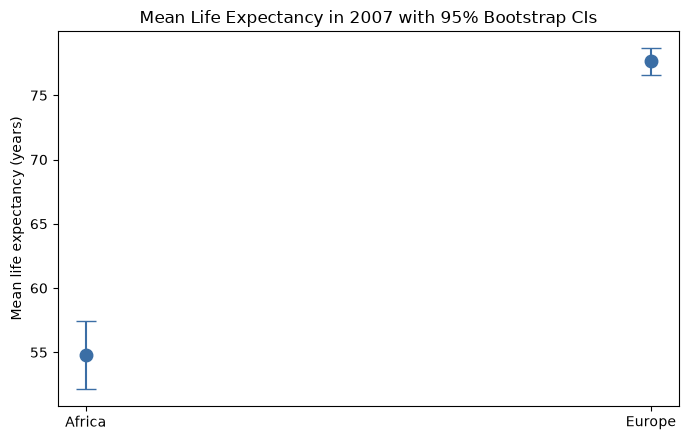

Africa: mean=54.81, 95% CI=(52.15, 57.44), n=52
Europe: mean=77.65, 95% CI=(76.57, 78.65), n=30


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])
    return float(values.mean()), float(ci_low), float(ci_high)

continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

means = np.array([result_a[0], result_b[0]])
lower_errors = means - np.array([result_a[1], result_b[1]])
upper_errors = np.array([result_a[2], result_b[2]]) - means

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=np.vstack([lower_errors, upper_errors]),
    fmt="o",
    markersize=9,
    capsize=7,
    color="#3b6ea5",
    ecolor="#3b6ea5",
)
ax.set_ylabel("Mean life expectancy (years)")
ax.set_title("Mean Life Expectancy in 2007 with 95% Bootstrap CIs")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=({result_a[1]:.2f}, {result_a[2]:.2f}), n={len(values_a)}")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=({result_b[1]:.2f}, {result_b[2]:.2f}), n={len(values_b)}")

**Reflection:** Africa has the wider 95% bootstrap confidence interval even though it has more countries in the 2007 sample than Europe. Its wider interval is therefore driven mainly by greater variation in life expectancy among countries; Europe's smaller sample works in the opposite direction but is not enough to outweigh Africa's higher spread.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

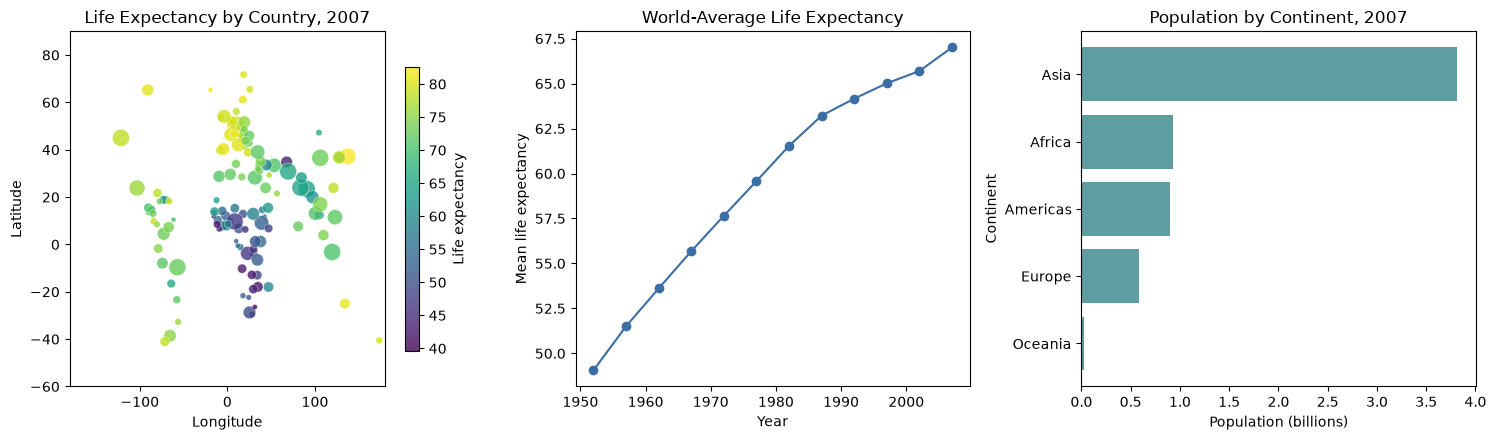

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

mapped = gap_latest.dropna(subset=["centroid_lon", "centroid_lat", "lifeExp"])
scatter = axes[0].scatter(
    mapped.centroid_lon,
    mapped.centroid_lat,
    c=mapped.lifeExp,
    cmap="viridis",
    s=np.clip(np.sqrt(mapped["pop"]) / 80, 12, 150),
    alpha=0.8,
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-60, 90)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Life Expectancy by Country, 2007")
fig.colorbar(scatter, ax=axes[0], shrink=0.8, label="Life expectancy")

world_trend = gapminder.groupby("year", as_index=False).lifeExp.mean()
axes[1].plot(world_trend.year, world_trend.lifeExp, marker="o", color="#3b6ea5")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean life expectancy")
axes[1].set_title("World-Average Life Expectancy")

continent_population = (
    gap_latest.groupby("continent", as_index=False)["pop"]
    .sum()
    .sort_values("pop")
)
axes[2].barh(continent_population.continent, continent_population["pop"] / 1e9, color="#5f9ea0")
axes[2].set_xlabel("Population (billions)")
axes[2].set_ylabel("Continent")
axes[2].set_title("Population by Continent, 2007")

plt.tight_layout()
plt.show()

**Reflection:** I would keep the world-average life-expectancy line because a five-second glance can show whether the long-term indicator is rising, flattening, or reversing. It best answers the monitoring question "Is the central development trend changing direction?"; the map and population bar are more useful when the director needs geographic or scale context.

## Task 5 — The Decision

I would standardize on per-capita or other rate-based choropleths whenever the goal is to compare country conditions, because raw totals largely encode population and land-area effects. A total should still be used when the policy question is explicitly about aggregate scale, but it must be labeled as such. For a journalist asking about one country, I would lead with local SHAP contributions because they explain the direction and size of each feature's contribution to that prediction; global importance answers a different question about the model overall. Mean life expectancy should never appear as a bare point estimate when it is used to compare continents or track sampled populations. A confidence interval should accompany the mean so readers can see the uncertainty caused by variation and sample size rather than treating a small difference as certain.